<a href="https://colab.research.google.com/github/azmain021/Machine-Learning-Basic/blob/ml1/Copy_of_CSE422_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("Customer_Category_Classifier_Dataset.csv")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8068 entries, 0 to 8067
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               8068 non-null   int64  
 1   Gender           8068 non-null   object 
 2   Ever_Married     7928 non-null   object 
 3   Age              8068 non-null   int64  
 4   Graduated        7990 non-null   object 
 5   Profession       7944 non-null   object 
 6   Work_Experience  7239 non-null   float64
 7   Spending_Score   8068 non-null   object 
 8   Family_Size      7733 non-null   float64
 9   Var_1            7992 non-null   object 
 10  Segmentation     8068 non-null   object 
dtypes: float64(2), int64(2), object(7)
memory usage: 693.5+ KB


In [ ]:
df.head()

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,462643,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4,A
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,462669,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6,A


In [ ]:
df.isnull().sum()

,0
ID,0
Gender,0
Ever_Married,140
Age,0
Graduated,78
Profession,124
Work_Experience,829
Spending_Score,0
Family_Size,335
Var_1,76


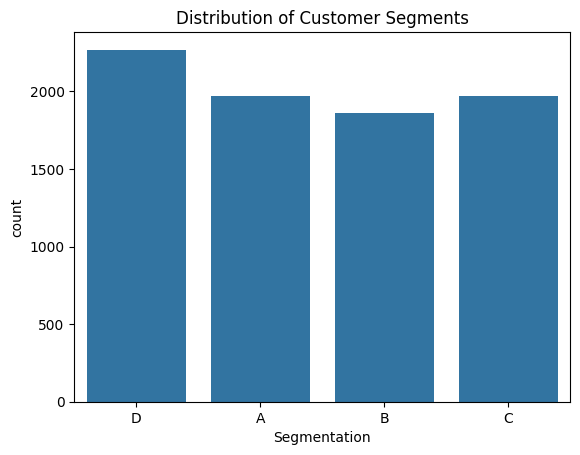

In [ ]:
sns.countplot(x='Segmentation', data=df)
plt.title('Distribution of Customer Segments')
plt.show()

In [ ]:
df = df.drop('ID', axis = 1)


In [ ]:
# Fill missing numerical values with the median
df['Work_Experience'].fillna(df['Work_Experience'].median(), inplace=True)
df['Family_Size'].fillna(df['Family_Size'].median(), inplace=True)

# Fill missing text/categorical values with the most frequent value (mode)
text_columns_with_nulls = ['Ever_Married', 'Graduated', 'Profession', 'Var_1']
for col in text_columns_with_nulls:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Print this to prove to your professor that there are 0 missing values left!
print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
Gender             0
Ever_Married       0
Age                0
Graduated          0
Profession         0
Work_Experience    0
Spending_Score     0
Family_Size        0
Var_1              0
Segmentation       0
dtype: int64


/tmp/ipykernel_3199/2982666627.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Work_Experience'].fillna(df['Work_Experience'].median(), inplace=True)
/tmp/ipykernel_3199/2982666627.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(v

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Initialize the encoder
le = LabelEncoder()

# A list of all your columns that currently contain text
text_cols = ['Gender', 'Ever_Married', 'Graduated', 'Profession', 'Spending_Score', 'Var_1', 'Segmentation']

# Loop through each column and convert the text to numeric codes
for col in text_cols:
    df[col] = le.fit_transform(df[col])

# Look at the first 5 rows to see the new fully-numeric dataset
print("\nData after converting text to numbers:")
print(df.head())


Data after converting text to numbers:
   Gender  Ever_Married  Age  Graduated  Profession  Work_Experience  \
0       1             0   22          0           5              1.0   
1       0             1   38          1           2              1.0   
2       0             1   67          1           2              1.0   
3       1             1   67          1           7              0.0   
4       0             1   40          1           3              1.0   

   Spending_Score  Family_Size  Var_1  Segmentation  
0               2          4.0      3             3  
1               0          3.0      3             0  
2               2          1.0      5             1  
3               1          2.0      5             1  
4               1          6.0      5             0  


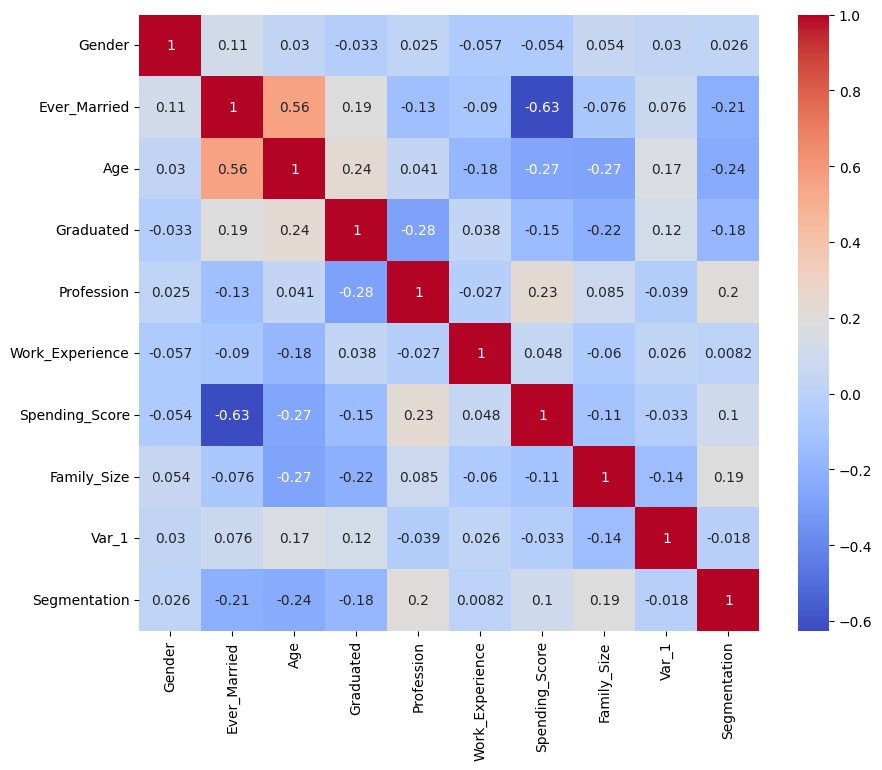

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('Segmentation', axis=1)
y = df['Segmentation']

# 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
#Step 5.1: K-Nearest Neighbors (KNN)
# Import the KNN classifier and accuracy metric
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

print("--- 1. K-Nearest Neighbors (KNN) ---")

# Initialize the model. We tell it to look at the 5 closest neighbors.
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train (fit) the model using the "Study Guide" (Training data)
knn_model.fit(X_train, y_train)

# Ask the trained model to take the "Final Exam" (Predict on Testing data)
knn_predictions = knn_model.predict(X_test)

# Grade the exam: Compare predictions to the actual answers (y_test)
knn_accuracy = accuracy_score(y_test, knn_predictions)
print(f"KNN Accuracy: {knn_accuracy * 100:.2f}%\n")

--- 1. K-Nearest Neighbors (KNN) ---
KNN Accuracy: 45.48%



In [ ]:
#Step 5.2: Decision Tree
# Import the Decision Tree classifier
from sklearn.tree import DecisionTreeClassifier

print("--- 2. Decision Tree ---")

# Initialize the model. random_state ensures we get the same results every time we run it.
dt_model = DecisionTreeClassifier(random_state=42)

# Train the model
dt_model.fit(X_train, y_train)

# Make predictions
dt_predictions = dt_model.predict(X_test)

# Grade the model
dt_accuracy = accuracy_score(y_test, dt_predictions)
print(f"Decision Tree Accuracy: {dt_accuracy * 100:.2f}%\n")

--- 2. Decision Tree ---
Decision Tree Accuracy: 41.82%



In [ ]:
#Step 5.3: Neural Network (MLPClassifier)
# Import the Multi-Layer Perceptron (Neural Network)
from sklearn.neural_network import MLPClassifier

print("--- 3. Neural Network (MLP) ---")

# Initialize the Neural Network.
# hidden_layer_sizes=(100, 50) means two hidden layers with 100 and 50 neurons.
# max_iter=1000 gives the network enough time to finish learning without timing out.
nn_model = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42)

# Train the model (This might take a few seconds longer than the others)
nn_model.fit(X_train, y_train)

# Make predictions
nn_predictions = nn_model.predict(X_test)

# Grade the model
nn_accuracy = accuracy_score(y_test, nn_predictions)
print(f"Neural Network Accuracy: {nn_accuracy * 100:.2f}%\n")

--- 3. Neural Network (MLP) ---
Neural Network Accuracy: 51.49%



--- 4. Unsupervised Learning (K-Means Clustering) ---


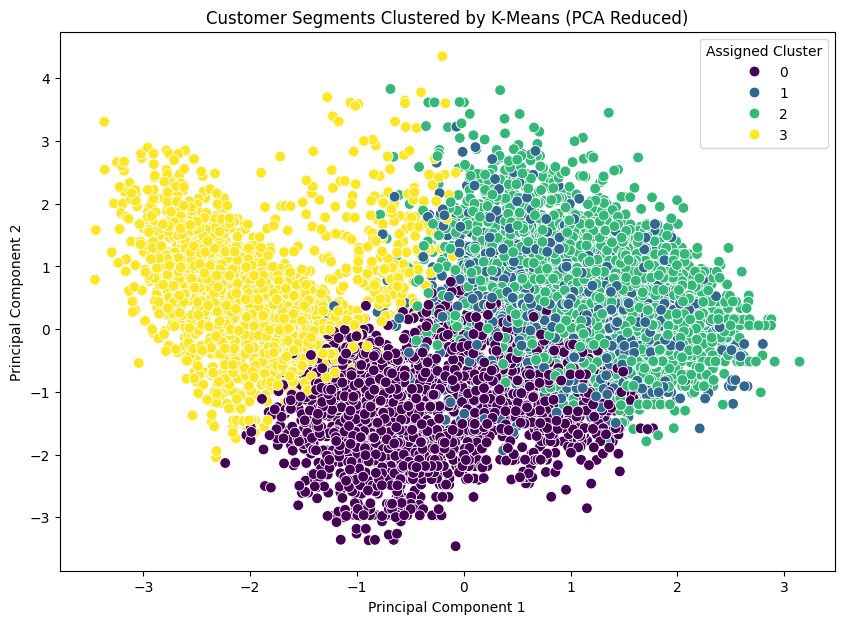

In [ ]:
#Step 5.4: Unsupervised Learning (K-Means & PCA)
# Import all required libraries
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


print("--- 4. Unsupervised Learning (K-Means Clustering) ---")

# RE-CREATE X_scaled right here so Colab cannot throw a NameError
X = df.drop('Segmentation', axis=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# We choose 4 clusters because the original target 'Segmentation' had 4 categories
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

# fit_predict calculates the clusters and assigns a cluster number to each customer
cluster_labels = kmeans.fit_predict(X_scaled)

# Now we use PCA to reduce the many features down to just 2 "Principal Components" for plotting
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Create the scatter plot to showcase the clusters
plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=cluster_labels, palette='viridis', s=60)

# Add titles and labels for the report
plt.title('Customer Segments Clustered by K-Means (PCA Reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Assigned Cluster')
plt.show()

--- 1. Precision & Recall (Classification Reports) ---
K-Nearest Neighbors Report:
              precision    recall  f1-score   support

           0       0.37      0.45      0.40       391
           1       0.33      0.33      0.33       369
           2       0.46      0.43      0.44       380
           3       0.65      0.58      0.61       474

    accuracy                           0.45      1614
   macro avg       0.45      0.45      0.45      1614
weighted avg       0.47      0.45      0.46      1614


Decision Tree Report:
              precision    recall  f1-score   support

           0       0.33      0.34      0.34       391
           1       0.30      0.32      0.31       369
           2       0.42      0.41      0.41       380
           3       0.60      0.57      0.58       474

    accuracy                           0.42      1614
   macro avg       0.41      0.41      0.41      1614
weighted avg       0.42      0.42      0.42      1614


Neural Network (MLP) Re

/tmp/ipykernel_3199/3081863204.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=accuracies, palette='Set2')


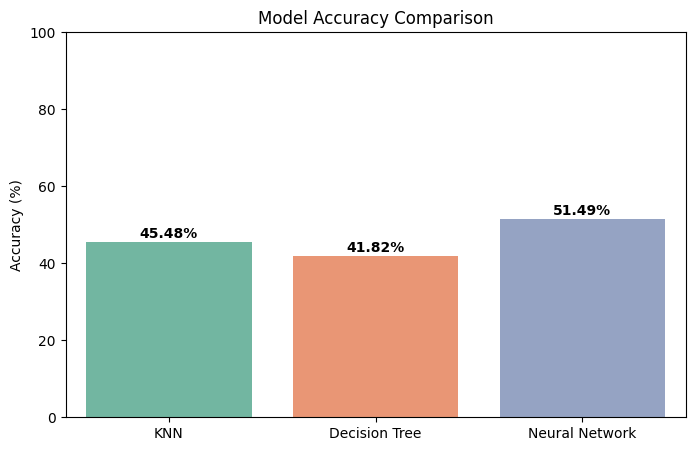

In [ ]:
#Step 6.1: Precision, Recall, and Accuracy Bar Chart
from sklearn.metrics import classification_report



print("--- 1. Precision & Recall (Classification Reports) ---")

# Print the detailed report for each model
print("K-Nearest Neighbors Report:")
print(classification_report(y_test, knn_predictions))

print("\nDecision Tree Report:")
print(classification_report(y_test, dt_predictions))

print("\nNeural Network (MLP) Report:")
print(classification_report(y_test, nn_predictions))

print("\n--- 2. Accuracy Comparison Bar Chart ---")

# Prepare data for the bar chart
models = ['KNN', 'Decision Tree', 'Neural Network']
# We calculate accuracy by checking how many predictions match the actual y_test answers
accuracies = [
    (knn_predictions == y_test).mean() * 100,
    (dt_predictions == y_test).mean() * 100,
    (nn_predictions == y_test).mean() * 100
]

# Create the bar chart
plt.figure(figsize=(8, 5))
sns.barplot(x=models, y=accuracies, palette='Set2')
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100) # Set y-axis from 0 to 100 for proper scale

# Add the exact percentage on top of each bar
for i, v in enumerate(accuracies):
    plt.text(i, v + 1, f"{v:.2f}%", ha='center', fontweight='bold')

plt.show()

--- 3. Confusion Matrices ---


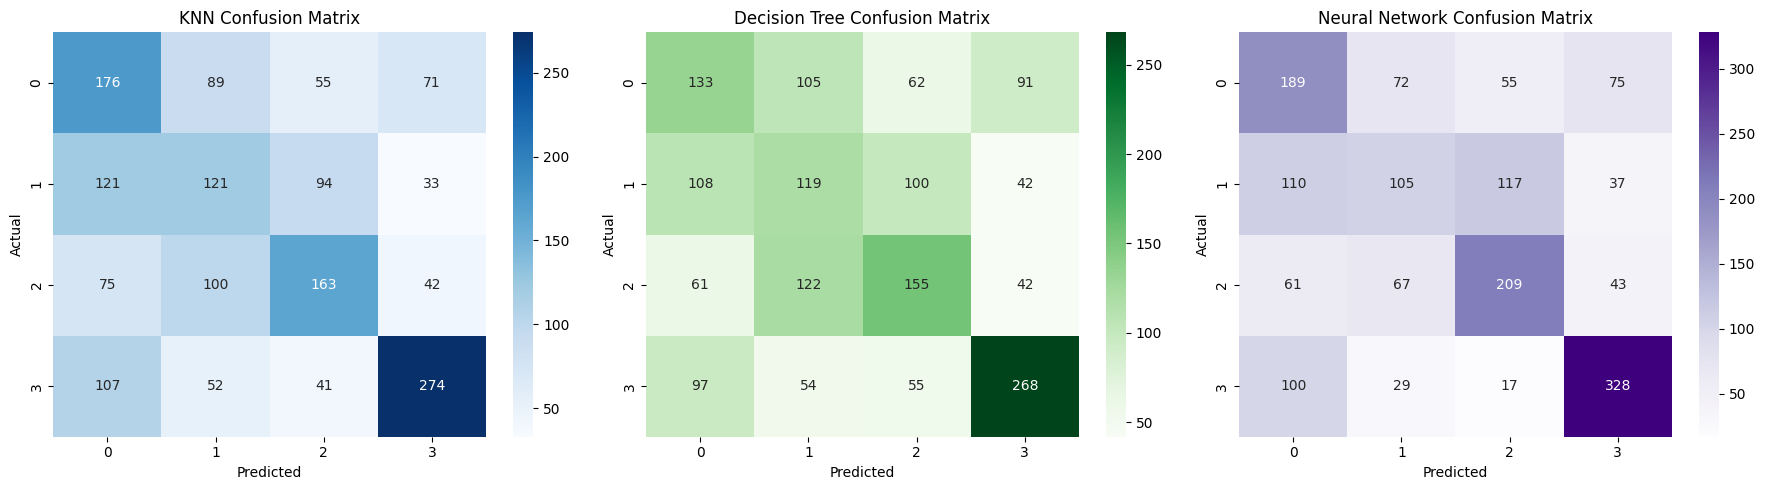

In [ ]:
#Step 6.2: Confusion Matrices
from sklearn.metrics import confusion_matrix

print("--- 3. Confusion Matrices ---")

# Calculate the confusion matrix for each model
cm_knn = confusion_matrix(y_test, knn_predictions)
cm_dt = confusion_matrix(y_test, dt_predictions)
cm_nn = confusion_matrix(y_test, nn_predictions)

# Set up a figure with 3 subplots (one for each model)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot KNN Matrix
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('KNN Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Plot Decision Tree Matrix
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Decision Tree Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

# Plot Neural Network Matrix
sns.heatmap(cm_nn, annot=True, fmt='d', cmap='Purples', ax=axes[2])
axes[2].set_title('Neural Network Confusion Matrix')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')

plt.tight_layout()
plt.show()

--- 4. ROC Curves and AUC Scores ---
KNN AUC Score: 0.6973
Decision Tree AUC Score: 0.6152
Neural Network AUC Score: 0.7702


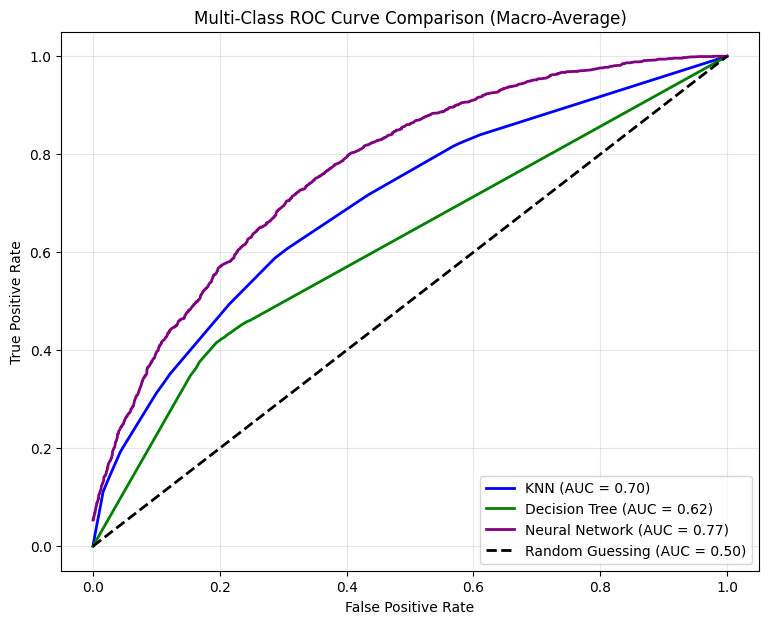

In [ ]:
#Step 6.3: ROC Curves and AUC Scores
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score
import numpy as np

print("--- 4. ROC Curves and AUC Scores ---")

# 1. Binarize the output for multi-class ROC calculation
y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3])
n_classes = y_test_bin.shape[1]

# 2. Get the prediction "probabilities" from each model
knn_probs = knn_model.predict_proba(X_test)
dt_probs = dt_model.predict_proba(X_test)
nn_probs = nn_model.predict_proba(X_test)

# 3. Print the AUC (Area Under Curve) Scores
# multi_class='ovr' means "One vs Rest", the standard for multi-class AUC
print(f"KNN AUC Score: {roc_auc_score(y_test, knn_probs, multi_class='ovr'):.4f}")
print(f"Decision Tree AUC Score: {roc_auc_score(y_test, dt_probs, multi_class='ovr'):.4f}")
print(f"Neural Network AUC Score: {roc_auc_score(y_test, nn_probs, multi_class='ovr'):.4f}")

# 4. Helper function to calculate the average ROC curve across all 4 classes
def get_macro_roc(y_true, y_probs):
    fpr_dict, tpr_dict = {}, {}
    for i in range(n_classes):
        fpr_dict[i], tpr_dict[i], _ = roc_curve(y_true[:, i], y_probs[:, i])

    # Combine all false positive rates
    all_fpr = np.unique(np.concatenate([fpr_dict[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr_dict[i], tpr_dict[i])

    mean_tpr /= n_classes
    return all_fpr, mean_tpr, auc(all_fpr, mean_tpr)

# 5. Calculate macro ROC for all three models
fpr_knn, tpr_knn, auc_knn_macro = get_macro_roc(y_test_bin, knn_probs)
fpr_dt, tpr_dt, auc_dt_macro = get_macro_roc(y_test_bin, dt_probs)
fpr_nn, tpr_nn, auc_nn_macro = get_macro_roc(y_test_bin, nn_probs)

# 6. Plot the ROC Curves
plt.figure(figsize=(9, 7))
plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {auc_knn_macro:.2f})', color='blue', linewidth=2)
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {auc_dt_macro:.2f})', color='green', linewidth=2)
plt.plot(fpr_nn, tpr_nn, label=f'Neural Network (AUC = {auc_nn_macro:.2f})', color='purple', linewidth=2)

# Plot the random guessing baseline
plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Guessing (AUC = 0.50)')

plt.title('Multi-Class ROC Curve Comparison (Macro-Average)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()